# Objective

## Dhaka regularly ranks among the most polluted cities in the world, and fine particulate matter (PM2.5) is the pollutant most closely linked to serious health risks for its residents. The objective of this project is to build a time series model that forecasts hourly PM2.5 concentrations in Dhaka for the next 24 to 72 hours, using recent air quality data and meteorological variables (temperature, humidity, wind speed, and precipitation) from the Open-Meteo APIs. The workflow covers data collection, cleaning, and exploratory analysis of daily and seasonal patterns, followed by a comparison of a seasonal naive baseline against statistical models (SARIMA, Prophet) and machine learning models (XGBoost, LightGBM) with lag and weather features. Models are evaluated with rolling-origin validation to avoid data leakage, and the best one is deployed as a live Streamlit app that refreshes automatically with the latest data, so anyone can see the current air quality and the upcoming forecast.

# Import Necessary Libraries

In [1]:
# Data collection and handling
import requests
import pandas as pd
import numpy as np
import time
from datetime import datetime, timedelta

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Time series analysis and statistical models
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

# Machine learning models and validation
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Saving the model for deployment
import joblib


D:\Jupyter lab\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# API feasibility Test

In [2]:


# Define the API URL
url = "https://air-quality-api.open-meteo.com/v1/air-quality"
params = {
    "latitude": 23.81,
    "longitude": 90.41,
    "hourly": "pm2_5,pm10",
    "past_days": 90,
    "forecast_days": 0,
    "timezone": "Asia/Dhaka",
}

# Fetch data from the API
response = requests.get(url, params=params, timeout=60)
response.raise_for_status()
data = response.json()



# Build DataFrame

In [3]:
hourly_data = data["hourly"]
df = pd.DataFrame({
    "time": hourly_data["time"],
    "pm2_5": hourly_data["pm2_5"],
    "pm10": hourly_data["pm10"],
})
df.head()

,time,pm2_5,pm10
0,2026-07-06T00:00,7.9,8.4
1,2026-07-06T01:00,7.6,8.1
2,2026-07-06T02:00,7.3,8.0
3,2026-07-06T03:00,6.5,7.2
4,2026-07-06T04:00,5.4,5.8


## Set data formats

In [4]:
df['time']=pd.to_datetime(df["time"])
df=df.set_index('time')
# Basic checks
print(df.shape)
print(df.index.min(), "->", df.index.max())
print("Frequency:", pd.infer_freq(df.index))
print("Null Values",df.isna().sum())
print(df.describe())

(2160, 2)
2026-07-06 00:00:00 -> 2026-10-03 23:00:00
Frequency: h
Null Values pm2_5    0
pm10     0
dtype: int64
             pm2_5         pm10
count  2160.000000  2160.000000
mean     22.892685    25.138333
std      18.195460    19.799485
min       3.200000     3.200000
25%      11.700000    12.800000
50%      17.300000    19.300000
75%      25.400000    28.300000
max     131.800000   135.500000


# Explore the Dataset

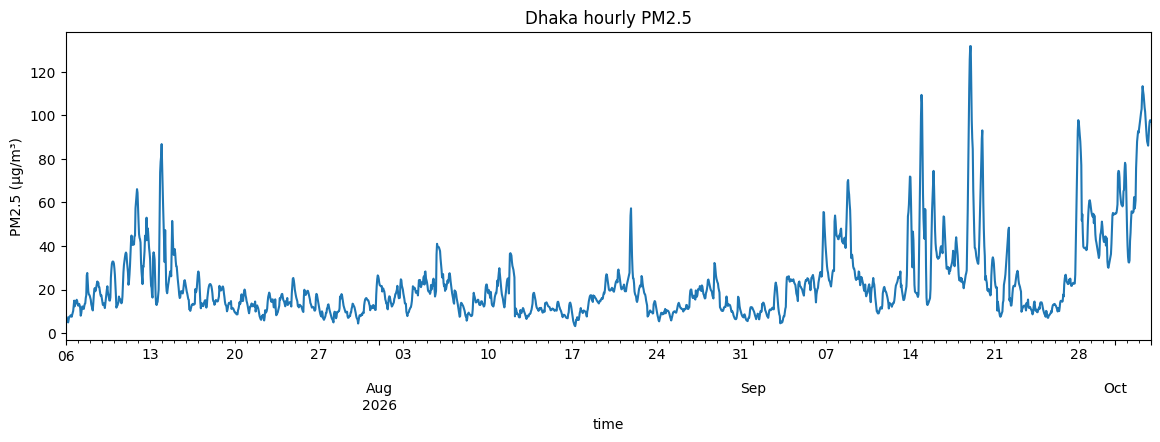

In [5]:
# 4. Plot the full series
df["pm2_5"].plot(figsize=(14, 4), title="Dhaka hourly PM2.5")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()

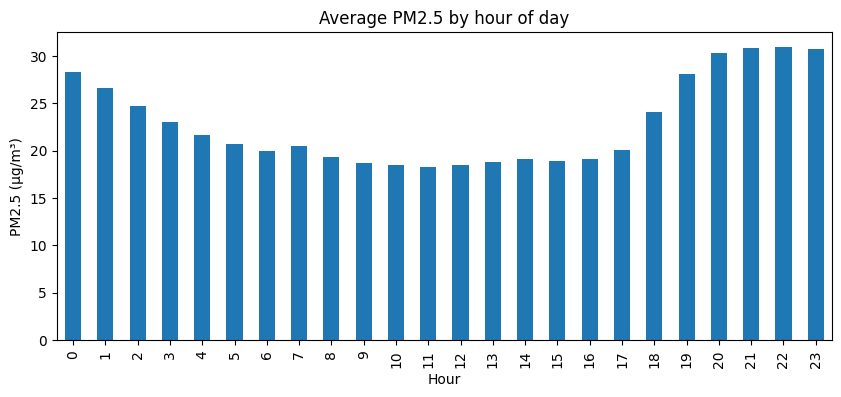

In [6]:
# 5. Average PM2.5 by hour of day
hourly_avg = df.groupby(df.index.hour)["pm2_5"].mean()
hourly_avg.plot(kind="bar", figsize=(10, 4), title="Average PM2.5 by hour of day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()